# 05 · What to control for — and what NOT to (pathmc)

**The decision.** Which variables go in the model? This is the question that
silently biases everything above it. Throw in "every column we have" and you'll
control for **mediators** (removing the effect you wanted) and **colliders**
(inventing an effect that isn't there). Leave out a real **confounder** and you keep
the bias you were trying to remove. This notebook is the "how did we know what to
control for?" slide — the one that makes the CMO trust the rest.

We let `pathmc` read the DAG and tell us (a) the admissible adjustment set, (b) which
tempting variables are *colliders* to avoid, and then we (c) bound the damage from an
**unobserved** confounder with a sensitivity analysis.

7-step contract, with identification (not estimation) as the whole point.


In [1]:
import os, warnings, numpy as np, pandas as pd, matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
import pathmc
from cmp import dgp, plots
plots.use_style()
FAST = os.environ.get("CMP_FAST", "1") == "1"
FIT = dict(draws=400, tune=400, chains=2) if FAST else dict(draws=1500, tune=1500, chains=4)
SEED = 17

## 2 · Simulate a ground truth

`email → spend` with a **true effect of €6**. The catch is the graph around it:

- **`loyalty`** is a **confounder** — it drives both who gets emailed and how much
  they spend. Must be controlled.
- **`responded`** is a **collider** — caused by *both* the email and the spend.
  Tempting to include ("engaged customers"), but conditioning on it manufactures
  bias.
- **`opened_email`** is a post-treatment descendant — another "don't touch" variable.


In [2]:
df, true_ate = dgp.dag_control_demo(n=1500, seed=SEED)
print(f"TRUE effect of email on spend = €{true_ate:.1f}")
df.head()

TRUE effect of email on spend = €6.0


,email,loyalty,opened_email,responded,spend
0,0.0,1.101262,0.0,1.0,28.034713
1,0.0,0.338431,1.0,1.0,22.256007
2,1.0,-0.539972,0.0,1.0,20.254489
3,0.0,-1.260242,1.0,1.0,22.776630
4,0.0,-1.894621,0.0,0.0,6.481503


## 3 · Identify — let the DAG choose the adjustment set

The **backdoor criterion**: an adjustment set $Z$ is admissible if it blocks every
backdoor path from treatment to outcome and contains no descendant of the treatment.
`pathmc` enumerates the admissible sets and flags colliders, straight from the graph
— *no data needed for this part*, because identification is about structure, not
numbers.


In [3]:
spec = '''
email        ~ b1*loyalty
opened_email ~ b2*email
responded    ~ b3*email + b4*spend
spend        ~ b5*email + b6*loyalty
'''
m = pathmc.model(spec, data=df)
print("Admissible adjustment set(s) for email → spend:", m.adjustment_sets("email", "spend"))
print("Identifiable:", m.is_identifiable("email", "spend"))
print()
for candidate in [{"loyalty"}, {"loyalty", "responded"}, {"loyalty", "opened_email"}]:
    warns = m.collider_warnings(candidate, "email", "spend")
    print(f"control for {candidate}:  " + ("; ".join(warns) if warns else "OK — no collider opened"))

Admissible adjustment set(s) for email → spend: [{'loyalty'}]
Identifiable: True

control for {'loyalty'}:  OK — no collider opened
control for {'loyalty', 'responded'}:  'responded' is a collider between 'email' and 'spend'. Conditioning on it may open a spurious path and introduce bias.
control for {'opened_email', 'loyalty'}:  OK — no collider opened


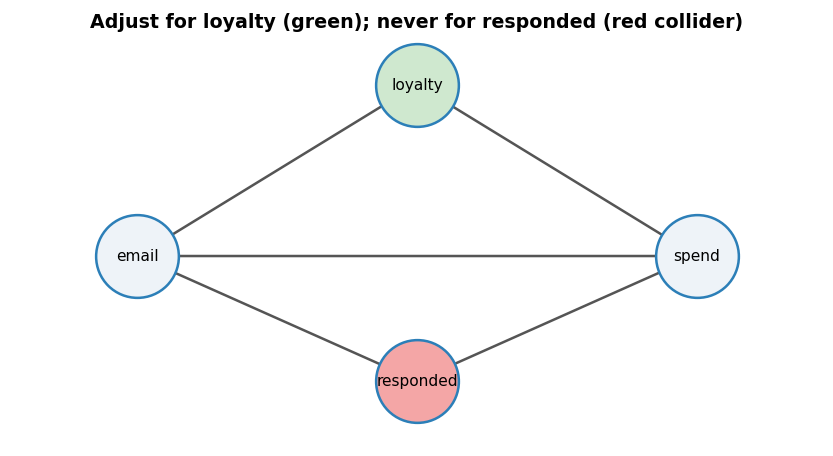

In [4]:
fig, ax = plt.subplots(figsize=(6.5, 3.6))
pos = {"loyalty": (0.5, 1.0), "email": (0.05, 0.45), "spend": (0.95, 0.45), "responded": (0.5, 0.05)}
edges = [("loyalty","email"),("loyalty","spend"),("email","spend"),("email","responded"),("spend","responded")]
plots.draw_dag(ax, pos, edges, node_colors={"loyalty":"#cfe8cf","responded":"#f4a6a6"},
               title="Adjust for loyalty (green); never for responded (red collider)")
fig.tight_layout()

## 4–5 · Estimate & Validate — right set vs wrong sets

We fit the email→spend effect under four control choices and compare to the true €6.
Only the DAG-endorsed set (`{loyalty}`) recovers it; the naive (no control) keeps the
confounding, and adding the collider `responded` re-introduces bias.


naive (nothing)                        € 9.43   (true €6.0, error +3.43)
{loyalty}  ✓ correct                   € 5.80   (true €6.0, error -0.20)
{loyalty, responded}  ✗ collider       € 5.35   (true €6.0, error -0.65)
{loyalty, opened_email}  ✗ post-treatment € 5.12   (true €6.0, error -0.88)


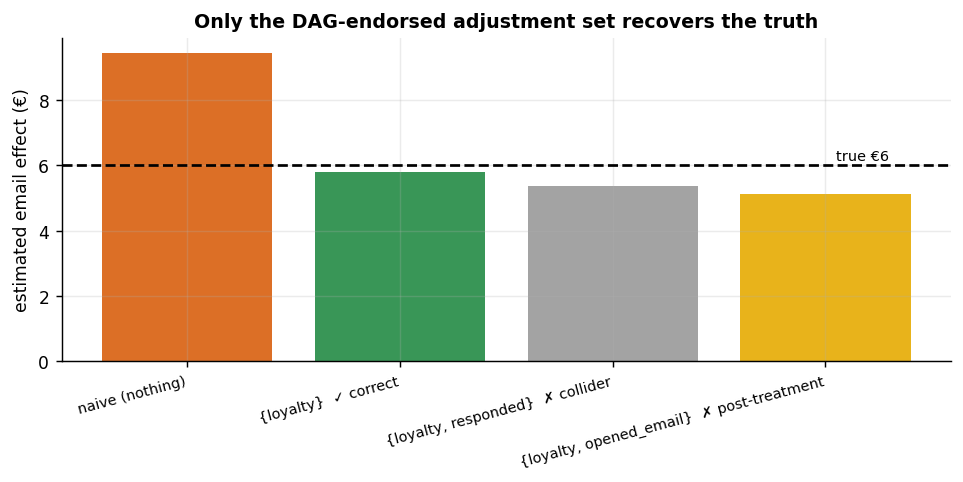

In [5]:
def ols_effect(data, controls):
    X = np.column_stack([np.ones(len(data)), data["email"].values] + [data[c].values for c in controls])
    beta, *_ = np.linalg.lstsq(X, data["spend"].values, rcond=None)
    return beta[1]

choices = {
    "naive (nothing)": [],
    "{loyalty}  ✓ correct": ["loyalty"],
    "{loyalty, responded}  ✗ collider": ["loyalty", "responded"],
    "{loyalty, opened_email}  ✗ post-treatment": ["loyalty", "opened_email"],
}
ests = {k: ols_effect(df, v) for k, v in choices.items()}
for k, v in ests.items():
    print(f"{k:38s} €{v:5.2f}   (true €{true_ate:.1f}, error {v-true_ate:+.2f})")

fig, ax = plt.subplots(figsize=(7.5, 3.8))
cols = [plots.ORANGE, plots.GREEN, plots.GREY, plots.GOLD]
ax.bar(range(len(ests)), list(ests.values()), color=cols, alpha=0.9)
ax.axhline(true_ate, color="k", ls="--"); ax.text(3.3, true_ate+0.15, f"true €{true_ate:.0f}", ha="right", fontsize=8)
ax.set_xticks(range(len(ests))); ax.set_xticklabels(list(ests.keys()), rotation=15, ha="right", fontsize=8)
ax.set_ylabel("estimated email effect (€)"); ax.set_title("Only the DAG-endorsed adjustment set recovers the truth")
fig.tight_layout()

## 6 · Decide, in euros — with a robustness statement

The whole value of this notebook is a **defensible spec**: we can tell a skeptical
CMO *"here's why we controlled for loyalty and here's why we did NOT control for
opens/responses."* But identification is untestable, so we also **bound the damage**
from an unobserved confounder: how strong would a hidden common cause of email and
spend have to be to overturn the conclusion? `pathmc.sensitivity` reports the tipping
point.


Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [sigma_spend, beta_spend, sigma_email, beta_email, beta_responded, beta_opened_email, sigma_responded, sigma_opened_email]


Sampling 2 chains for 400 tune and 400 draw iterations (800 + 800 draws total) took 3 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


Observed adjusted ATE           €5.82  (true €6.0)
Tipping point (confounder str.) 5.82
Worst-case P(sign flips) in grid 0.00  → across the swept confounder strengths, the effect never flips sign (robust)


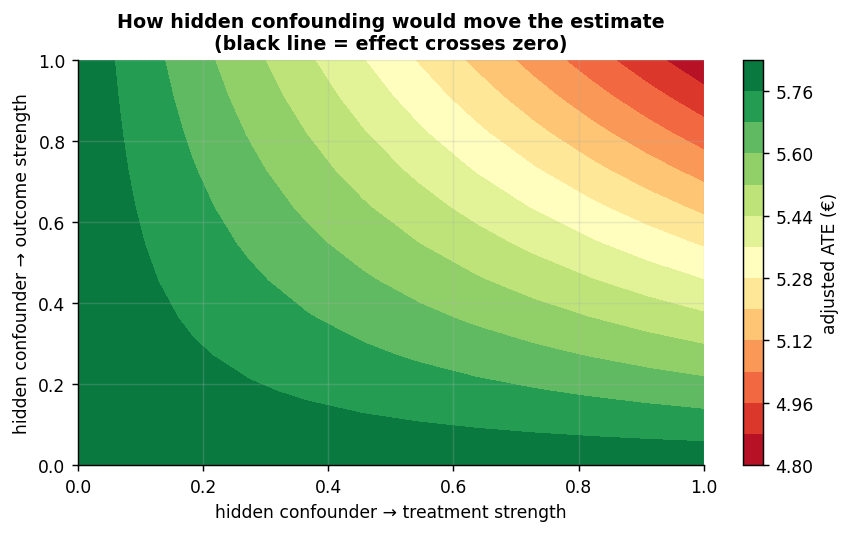

In [6]:
m.fit(random_seed=SEED, progressbar=False, **FIT)
sens = m.sensitivity("spend", "email", n_grid=12)
adj = np.asarray(sens.adjusted_ate_mean)          # (gamma × delta) grid of adjusted ATE
psc = np.asarray(sens.prob_sign_change)           # grid of P(effect flips sign)
print(f"Observed adjusted ATE           €{float(sens.observed_ate):.2f}  (true €{true_ate:.1f})")
print(f"Tipping point (confounder str.) {float(sens.tipping_point):.2f}")
print(f"Worst-case P(sign flips) in grid {psc.max():.2f}  "
      f"→ across the swept confounder strengths, the effect "
      + ("can flip sign" if psc.max() > 0.05 else "never flips sign (robust)"))

# contour of the adjusted ATE as the hidden confounder's two strengths grow
g, d = np.meshgrid(sens.gamma_values, sens.delta_values, indexing="ij")
fig, ax = plt.subplots(figsize=(6.8, 4.2))
cs = ax.contourf(g, d, adj, levels=12, cmap="RdYlGn")
ax.contour(g, d, adj, levels=[0], colors="k", linewidths=1.5)   # sign-flip boundary
plt.colorbar(cs, ax=ax, label="adjusted ATE (€)")
ax.set_xlabel("hidden confounder → treatment strength")
ax.set_ylabel("hidden confounder → outcome strength")
ax.set_title("How hidden confounding would move the estimate\n(black line = effect crosses zero)")
fig.tight_layout()

## 7 · Caveats

- **The graph is an assumption.** `pathmc` gives the *correct* adjustment set **for
  the DAG you drew**. If the true graph differs (a missing arrow, a reversed edge),
  so does the advice. The DAG should encode domain knowledge you can defend.
- **Colliders hide in "obvious" controls.** "Engaged", "responded", "opened",
  "clicked" are almost always post-treatment — excluding them feels wrong to
  practitioners and is exactly right.
- **Front-door as a fallback.** If a $T\!-\!Y$ confounder is genuinely unmeasured but
  a fully-mediating measured variable exists, the front-door adjustment can still
  identify the effect — a tool to keep in reserve.
- **Sensitivity ≠ proof.** A high tipping point means "robust to plausible hidden
  confounding," not "unconfounded." Pair it with the domain expert's judgement about
  what could plausibly be missing.
